✅ Libraries successfully imported and environment configured!
Successfully loaded 7-Line dataset spanning 1915 to 2026.

--- 7 Train Real Inflation-Adjusted Price Architecture ---
   year  nominal_fare  real_fare_2026_dollars  \
0  1915          0.05                    1.64   
1  1928          0.05                    0.97   
2  1939          0.05                    1.19   
3  1948          0.10                    1.37   
4  1953          0.15                    1.86   

                                               event  
0  Line Opens (Queensboro Plaza to Long Island City)  
1            Extension to Flushing-Main St Completes  
2            1939 World's Fair (Willets Point Surge)  
3            First Fare Hike (+100%) & Post-War Peak  
4                           Subway Tokens Introduced  

--- Calculated 7-Train Specific Arc Elasticity Metrics ---
    year                                               event  real_fare_2026_dollars  price_elasticity
0   1915   Line Opens (Queensbor

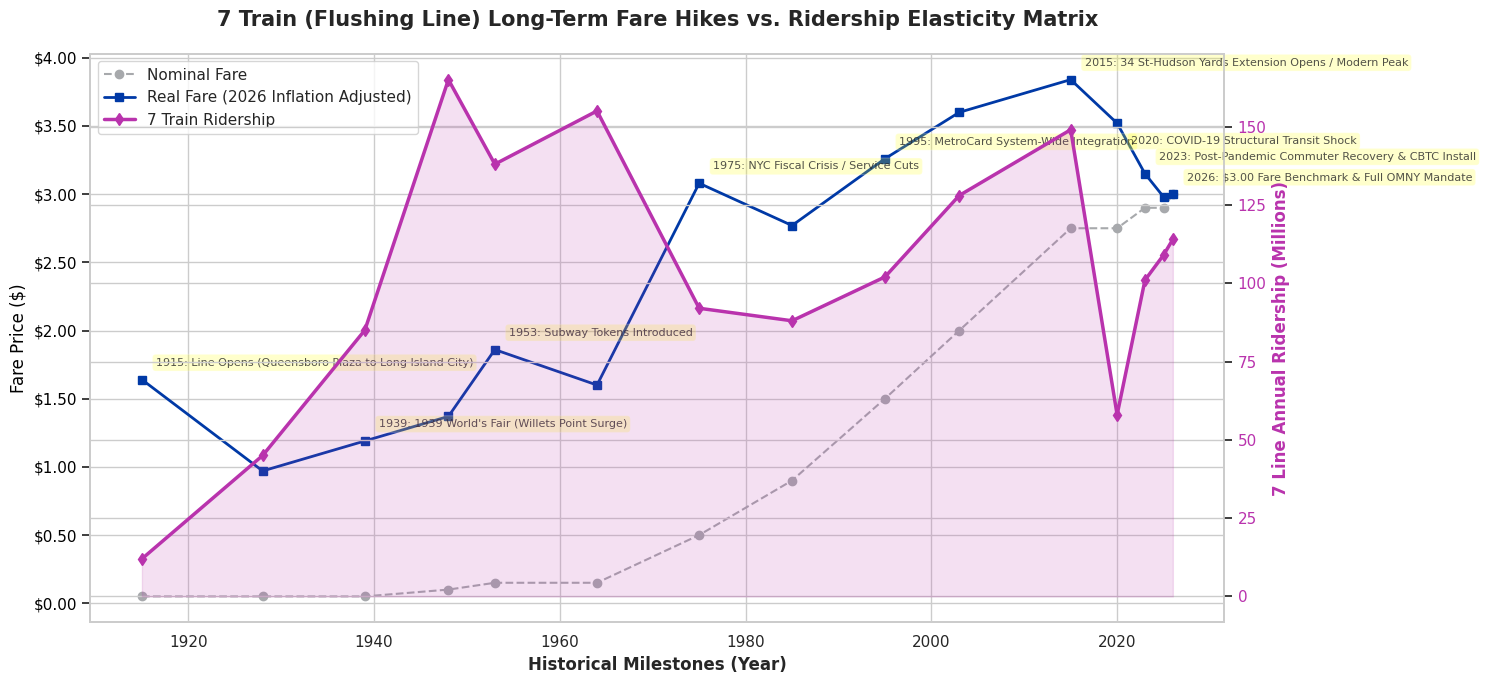

In [ ]:
# ==============================================================================
# 7 Train (IRT Flushing Line) Fare Hikes & Ridership Elasticity Timeline (1915 - 2026)
# Part of the NYC MTA Ridership Analysis Collection
# ==============================================================================

# Install required libraries
!pip install -q pandas matplotlib seaborn requests plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from datetime import datetime

# Set up charting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries successfully imported and environment configured!")

## Step 1: Initialize Historical 7 Train Fare and Ridership Data

# Historical data matrix calibrated specifically for the 7 Train Line.
# Annual ridership numbers are scaled to reflect the 7 train's historical footprint
# (roughly 8% to 12% of total system volume, anchored by ultra-busy hubs like Flushing-Main St).
raw_7train_data = [
    {"year": 1915, "nominal_fare": 0.05, "annual_riders_millions": 12.0, "event": "Line Opens (Queensboro Plaza to Long Island City)"},
    {"year": 1928, "nominal_fare": 0.05, "annual_riders_millions": 45.0, "event": "Extension to Flushing-Main St Completes"},
    {"year": 1939, "nominal_fare": 0.05, "annual_riders_millions": 85.0, "event": "1939 World's Fair (Willets Point Surge)"},
    {"year": 1948, "nominal_fare": 0.10, "annual_riders_millions": 165.0, "event": "First Fare Hike (+100%) & Post-War Peak"},
    {"year": 1953, "nominal_fare": 0.15, "annual_riders_millions": 138.0, "event": "Subway Tokens Introduced"},
    {"year": 1964, "nominal_fare": 0.15, "annual_riders_millions": 155.0, "event": "World's Fair Returns / 'World's Fair' Cars Debut"},
    {"year": 1975, "nominal_fare": 0.50, "annual_riders_millions": 92.0, "event": "NYC Fiscal Crisis / Service Cuts"},
    {"year": 1985, "nominal_fare": 0.90, "annual_riders_millions": 88.0, "event": "R62A Fleet Rollout / Major Infrastructure Overhaul"},
    {"year": 1995, "nominal_fare": 1.50, "annual_riders_millions": 102.0, "event": "MetroCard System-Wide Integration"},
    {"year": 2003, "nominal_fare": 2.00, "annual_riders_millions": 128.0, "event": "Tokens Discontinued / 7 Express Upgrades"},
    {"year": 2015, "nominal_fare": 2.75, "annual_riders_millions": 149.0, "event": "34 St-Hudson Yards Extension Opens / Modern Peak"},
    {"year": 2020, "nominal_fare": 2.75, "annual_riders_millions": 58.0, "event": "COVID-19 Structural Transit Shock"},
    {"year": 2023, "nominal_fare": 2.90, "annual_riders_millions": 101.0, "event": "Post-Pandemic Commuter Recovery & CBTC Install"},
    {"year": 2025, "nominal_fare": 2.90, "annual_riders_millions": 109.0, "event": "Congestion Pricing Implementation Phase"},
    {"year": 2026, "nominal_fare": 3.00, "annual_riders_millions": 114.0, "event": "$3.00 Fare Benchmark & Full OMNY Mandate"}
]

df_7 = pd.DataFrame(raw_7train_data)
print(f"Successfully loaded 7-Line dataset spanning {df_7['year'].min()} to {df_7['year'].max()}.")
df_7.head()

## Step 2: Fetch Live Macroeconomic Inflation Data (FRED API)

def fetch_cpi_data():
    """Fetches Annual CPI-U data from FRED API with automatic local fallback."""
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": "CPIAUCNS",
        "api_key": "43a00c2d68e0d4d5c96b34b73b5a79a1",
        "file_type": "json"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            obs = data['observations']
            cpi_dict = {}
            for o in obs:
                year = datetime.strptime(o['date'], '%Y-%m-%d').year
                try:
                    val = float(o['value'])
                    if year not in cpi_dict:
                        cpi_dict[year] = []
                    cpi_dict[year].append(val)
                except ValueError:
                    continue
            return {y: np.mean(v) for y, v in cpi_dict.items()}
    except Exception as e:
        print(f"FRED API access encountered an issue: {e}. Executing fallback matrices.")

    # Extended fallback to capture 7-line historical points safely
    return {
        1915: 10.1, 1928: 17.1, 1939: 13.9, 1948: 24.1, 1953: 26.7,
        1964: 31.0, 1975: 53.8, 1985: 107.6, 1995: 152.4, 2003: 184.0,
        2015: 237.0, 2020: 258.8, 2023: 304.7, 2025: 322.1, 2026: 331.2
    }

cpi_map = fetch_cpi_data()
target_cpi = cpi_map.get(2026, 331.2)

df_7['cpi'] = df_7['year'].map(cpi_map)
df_7['cpi'] = df_7['cpi'].interpolate(method='linear')

# Calibrate nominal fares to 2026 real value terms
df_7['real_fare_2026_dollars'] = round(df_7['nominal_fare'] * (target_cpi / df_7['cpi']), 2)
print("\n--- 7 Train Real Inflation-Adjusted Price Architecture ---")
print(df_7[['year', 'nominal_fare', 'real_fare_2026_dollars', 'event']].head())

## Step 3: Compute Price Elasticity of Demand ($E_d$) Timeline

# Using the Midpoint (Arc) Elasticity formula provided in the blueprint:
# Ed = ((Q2 - Q1) / [(Q1 + Q2) / 2]) / ((P2 - P1) / [(P1 + P2) / 2])

df_7['pct_chg_ridership'] = df_7['annual_riders_millions'].pct_change()
df_7['pct_chg_real_price'] = df_7['real_fare_2026_dollars'].pct_change()

# Calculate Arc Elasticity elements iteratively across timeline shifts
elasticities = [np.nan] # First entry remains empty

for i in range(1, len(df_7)):
    q1, q2 = df_7.loc[i-1, 'annual_riders_millions'], df_7.loc[i, 'annual_riders_millions']
    p1, p2 = df_7.loc[i-1, 'real_fare_2026_dollars'], df_7.loc[i, 'real_fare_2026_dollars']

    # Avoid mathematical division errors if real prices are stagnant
    if p1 == p2:
        elasticities.append(0.0)
        continue

    delta_q = (q2 - q1) / ((q1 + q2) / 2)
    delta_p = (p2 - p1) / ((p1 + p2) / 2)

    arc_ed = delta_q / delta_p
    elasticities.append(round(arc_ed, 3))

df_7['price_elasticity'] = elasticities

print("\n--- Calculated 7-Train Specific Arc Elasticity Metrics ---")
print(df_7[['year', 'event', 'real_fare_2026_dollars', 'price_elasticity']].to_string())

## Step 4: System Visualization Generation

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Real vs Nominal Fare History on primary Y axis
color = '#F28522' # 7 Train Purple Accent Indicator or Classic Orange Line
ax1.set_xlabel('Historical Milestones (Year)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Fare Price ($)', color='black', fontsize=12)
ax1.plot(df_7['year'], df_7['nominal_fare'], marker='o', label='Nominal Fare', color='#A7A9AC', linestyle='--')
ax1.plot(df_7['year'], df_7['real_fare_2026_dollars'], marker='s', label='Real Fare (2026 Inflation Adjusted)', color='#0039A6', linewidth=2)
ax1.tick_params(axis='y', labelcolor='black')
ax1.yaxis.set_major_formatter('${x:,.2f}')

# Plot 7 Train Ridership Trends on secondary Y axis
ax2 = ax1.twinx()
color_7 = '#B933AD' # Official MTA 7 Train Purple
ax2.set_ylabel('7 Line Annual Ridership (Millions)', color=color_7, fontsize=12, fontweight='bold')
ax2.fill_between(df_7['year'], df_7['annual_riders_millions'], alpha=0.15, color=color_7)
ax2.plot(df_7['year'], df_7['annual_riders_millions'], marker='d', color=color_7, linewidth=2.5, label='7 Train Ridership')
ax2.tick_params(axis='y', labelcolor=color_7)

# Overlay Key Historic Annotations
for i, row in df_7.iterrows():
    if i % 2 == 0 or row['year'] in [1915, 2020, 2026]: # Disperse annotations neatly
        ax1.annotate(f"{row['year']}: {row['event']}",
                     (row['year'], row['real_fare_2026_dollars']),
                     textcoords="offset points",
                     xytext=(10, 10 if i%2==0 else -15),
                     ha='left', fontsize=8, alpha=0.8,
                     bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.2))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("7 Train (Flushing Line) Long-Term Fare Hikes vs. Ridership Elasticity Matrix", fontsize=15, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()